# Testing the Gammapy plugin (instrument VERITAS) for 3ML

Anjana Kaushik Talluri

Current status of things:

We have a working Gammapy plugin for threeML (for the IACT instrument, VERITAS) designed for the likelihood fitting of a point source (specifically, the Crab Nebula) with any 1-D spectrum. This is based on J. Michael's version of the code has a neat Astromodel-Gammapy model converter that also takes care of updating the function parameters each time, so we don't have to do that part by hand. There are certain parts of the gammapy plugin that will have to be generalized (e.g., the coordinates for the exclusion regions are hard-coded). Refer to my notes for more info. 

This notebook includes the following:

1. Fitting of a point source (Crab) with a simple power law spectrum using the updated version of the Gammapy plugin in threeML for VERITAS that incorporates J. Michael's Astromodel-Gammapy model converter. 

2. Fitting of the same point source (Crab) with a simple power law spectrum using the Fermipy plugin in threeML. 

3. Fitting of the same point source (Crab) with a simple power law spectrum using the HAWC plugin in threeML.

4. Joint fitting of the same point source (Crab) with a simple power law spectrum using the Gammapy plugin for VERITAS, the Fermipy plugin, and the HAWC plugin. 

5. Fitting of a point source (Crab) with a log Parabola spectrum using the updated version of the Gammapy plugin in threeML for VERITAS that incorporates J. Michael's Astromodel-Gammapy model converter. 

6. Fitting of the same point source (Crab) with a log Parabola spectrum using the Fermipy plugin in threeML. 

7. Fitting of the same point source (Crab) with a log Parabola  spectrum using the HAWC plugin in threeML.

8. Joint fitting of the same point source (Crab) with a log Parabola spectrum using the Gammapy plugin for VERITAS, the Fermipy plugin, and the HAWC plugin. 

# Import statements

Refer to my notes for info/tips on installing fermipy and the threeML plugins

In [1]:
import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")



import matplotlib.pyplot as plt

import astropy.units as u
from threeML import *
from threeML.io.package_data import get_path_of_data_file



import warnings

warnings.simplefilter("ignore")
import numpy as np

np.seterr(all="ignore")
import shutil
from IPython.display import Image, display
import glob
from pathlib import Path
import matplotlib as mpl
from matplotlib import pyplot as plt
from astropy.io import fits as pyfits
import scipy as sp


from threeML import *





15:42:44 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=915616;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=467683;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py#47\47]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=717376;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=175190;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/functions.py#68\68]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=296997;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=910970;file:///home/tobi/sw/astromodels/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=517832;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=121117;file:///home/tobi/sw/threeML/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=783186;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=381205;file:///home/tobi/sw/threeML/threeML/__init__.py#40\40]8;;\

...

15:42:45 WARNING   ROOT minimizer not available                                                ]8;id=281171;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=137380;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py#1345\1345]8;;\

         WARNING   Multinest minimizer not available                                           ]8;id=57837;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=270520;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py#1357\1357]8;;\

         WARNING   PyGMO is not available                                                      ]8;id=785220;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py\minimization.py]8;;\:]8;id=165682;file:///home/tobi/sw/threeML/threeML/minimizer/minimization.py#1369\1369]8;;\

15:42:45 WARNING   The cthreeML package is not installed. You will not be able to use plugins which  ]8;id=80508;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=274670;file:///home/tobi/sw/threeML/threeML/__init__.py#94\94]8;;\
                  require the C/C++ interface (currently HAWC)                                                     

         WARNING   Could not import plugin HAWCLike.py. Do you have the relative instrument         ]8;id=400957;file:///home/tobi/sw/threeML/threeML/__init__.py\__init__.py]8;;\:]8;id=871785;file:///home/tobi/sw/threeML/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

In [2]:
from astromodels import Powerlaw, Log_parabola
from gammapy_plugin.model_converter import SpectralModelGenerator
import astropy.units as u
import numpy as np

# Individual and Joint fit for simple power law spectrum

# Likelihood fitting of a point source (Crab) with a simple power law spectrum using VERITAS in Gammapy

Define the point source and assign the power law spectrum to it. Initialize the parameters (pivot, K, index)

In [3]:

spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things in J. Michael's function
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [4]:

veritas_model = Model(source)
veritas_model.display()
#ene = np.array([1,10,100])



Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [5]:
import gammapy_plugin.model_converter

from gammapy_plugin.GammapyLike import GammapyLike

Let’s create an instance of the plugin

In [6]:
VERITAS = GammapyLike("VERITAS", config_file="../examples/config.yaml")

In [7]:
veritas_data = DataList(VERITAS)

In [8]:
veritas_jl = JointLikelihood(veritas_model, veritas_data, verbose=False)
# change verbose to true if you want more info on how it is running

15:42:47 INFO      set the minimizer to minuit                                             ]8;id=636404;file:///home/tobi/sw/threeML/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=458725;file:///home/tobi/sw/threeML/threeML/classicMLE/joint_likelihood.py#1045\1045]8;;\

Note: JointLikelihood can take one or more models. We simply need to build the data list, create the joint likelihood and run the fit. Refer to the joint fitting section below for an example

In [9]:
veritas_res = veritas_jl.fit()
print(veritas_res)

         WARNING   49.0 percent of samples have been thrown away because they failed the   ]8;id=835025;file:///home/tobi/sw/threeML/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=419638;file:///home/tobi/sw/threeML/threeML/analysis_results.py#1740\1740]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

Best fit values:

,result,unit
parameter,,
crab.spectrum.main.Powerlaw.K,(10.000 +/- 0.007) x 10^-7,1 / (keV s cm2)
crab.spectrum.main.Powerlaw.index,-2.4964 +/- 0.0015,


Correlation matrix:

1.00,-0.03
-0.03,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
VERITAS,30.159112
total,30.159112


Values of statistical measures:

,statistical measures
AIC,64.681861
BIC,67.485262


(                                          value  negative_error  \
crab.spectrum.main.Powerlaw.K      9.999994e-07      999.030609   
crab.spectrum.main.Powerlaw.index -2.496410e+00       -0.001406   

                                   positive_error       error             unit  
crab.spectrum.main.Powerlaw.K          999.854210  999.442410  1 / (keV s cm2)  
crab.spectrum.main.Powerlaw.index        0.001417    0.001411                   ,          -log(likelihood)
VERITAS         30.159112
total           30.159112)


processing MLE analyses:   0%|                                                                                …

Propagating errors:   0%|                                                                                     …

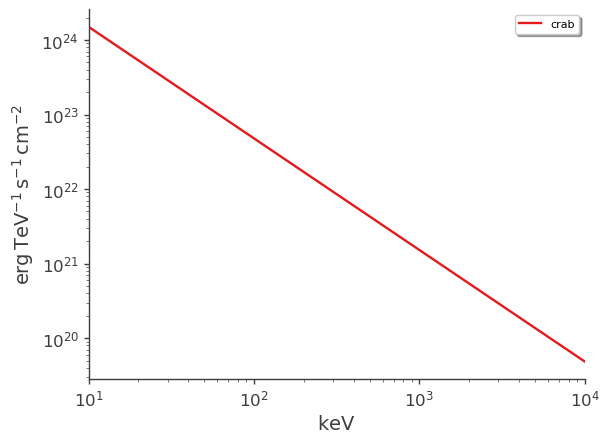

In [10]:
_ = plot_spectra(veritas_jl.results, flux_unit='erg/(cm2 s TeV)')


processing MLE analyses:   0%|                                                                                …

Propagating errors:   0%|                                                                                     …

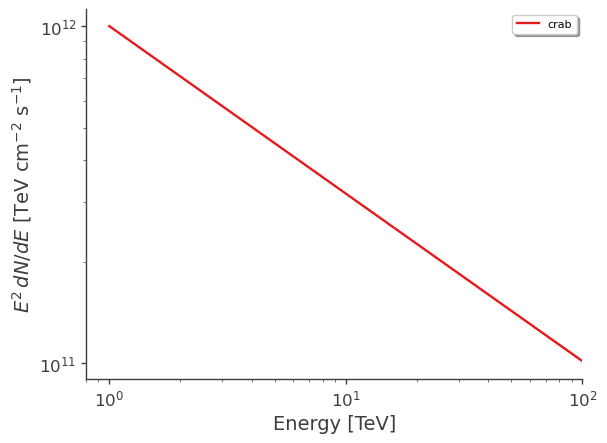

In [11]:
ver_results = veritas_jl.results
ver_results.write_to("crab_veritas_fit.fits", overwrite=True)
ver_results.optimized_model.save("crab_veritas_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    ver_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Likelihood fitting of a point source (Crab) with a simple power law spectrum using the Fermipy plugin in threeML

In [12]:
lat_catalog = FermiLATSourceCatalog()

ra, dec, table = lat_catalog.search_around_source("Crab", radius=0.004)

table

Trying https://heasarc.gsfc.nasa.gov/cgi-bin/vo/cone/coneGet.pl?table=fermilpsc&


name,source_type,short_source_type,ra,dec,assoc_name,tevcat_assoc,Search_Offset
,,,deg,deg,,,
object,str18,object,float64,float64,object,object,float64
4FGL J0534.5+2201s,pulsar wind nebula,PWN,83.6331,22.0199,Crab Nebula,Crab,0.1552
4FGL J0534.5+2201i,pulsar wind nebula,PWN,83.6330,22.0200,Crab Nebula,Crab,0.1597


In [13]:
spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [14]:
fermi_model = Model(source)
fermi_model.display()

Model summary:
==============

                  N
Point sources     1
Extended sources  0
Particle sources  0

Free parameters (2):
--------------------

                                  value min_value max_value            unit
crab.spectrum.main.Powerlaw.K       0.0       0.0    1000.0  TeV-1 s-1 cm-2
crab.spectrum.main.Powerlaw.index -2.53     -10.0      10.0                

Fixed parameters (3):
(abridged. Use complete=True to see all fixed parameters)


Properties (0):
--------------------

(none)


Linked parameters (0):
----------------------

(none)

Independent variables:
----------------------

(none)

Linked functions (0):
----------------------

(none)

In [15]:
ra = 83.63
dec = 22.01

In [16]:
# Download data from Jan 01 2010 to February 1 2010

tstart = "2010-01-01 00:00:00"
tstop = "2010-02-01 00:00:00"

# Note that this will understand if you already download these files, and will
# not do it twice unless you change your selection or the outdir

evfile, scfile = download_LAT_data(
    ra,
    dec,
    20.0,
    tstart,
    tstop,
    time_type="Gregorian",
    destination_directory="Crab_data",
)

15:43:03 INFO      Query parameters:                                                       ]8;id=877350;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=382739;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#262\262]8;;\

         INFO                          coordfield = 83.6300,22.0100                        ]8;id=829151;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=570653;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                         coordsystem = J2000                                  ]8;id=744977;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=902647;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          shapefield = 20.0                                   ]8;id=35984;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=83986;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                           timefield = 2010-01-01 00:00:00,2010-02-01         ]8;id=525588;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=26083;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\
                  00:00:00                                                                                         

...

         INFO                         destination = query                                  ]8;id=605844;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=112628;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO                          spacecraft = checked                                ]8;id=426262;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=372585;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#266\266]8;;\

         INFO      Query ID: e94fe495b65679baa926097eebf7f7fd                              ]8;id=477923;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=959490;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#271\271]8;;\

         WARNING   Existing event file                                                     ]8;id=174269;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=479256;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#316\316]8;;\
                  [PosixPath('/home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L2412020725                         
                  0949176D7595_PH00.fits')] and Spacecraft file                                                    
                  /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524                         
                  _SC00.fits correspond to the same selection. We assume you did not                               
                  tamper with them, so we will return those instead of downloading them                            
                  again. If you want to download them again, remove them from the outdir                           

         WARNING   Existing merged event file                                               ]8;id=828986;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py\download_LAT_data.py]8;;\:]8;id=903932;file:///home/tobi/sw/threeML/threeML/utils/data_download/Fermi_LAT/download_LAT_data.py#88\88]8;;\
                  /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097                        
                  eebf7f7fd_FT1.fits correspond to the same selection. We assume you did                           
                  not tamper with it, so we will return it instead of merging it again. If                         
                  you want to redo the FT1 file again, remove it from the outdir                                   

In [17]:
import fermipy

In [18]:
config = FermipyLike.get_basic_config(
    evfile=evfile,
    scfile=scfile,
    ra=ra,
    dec=dec,
    fermipy_verbosity=1,
    fermitools_chatter=0,
)

# See what we just got

config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524_SC00.fits
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524_SC00.fits
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

In [19]:
LAT = FermipyLike("LAT", config)
config.display()

binning:
  binsperdec: 8
  binsz: 0.1
  roiwidth: 10.0
data:
  evfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
  scfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524_SC00.fits
fileio:
  outdir: __8a152570c38eb6d74f9fe58e8079f9dd
logging:
  chatter: 0
  verbosity: 1
selection:
  dec: 22.01
  emax: 100000.0
  emin: 100.0
  evclass: 128
  evtype: 3
  filter: DATA_QUAL>0 && LAT_CONFIG==1
  ra: 83.63
  tmax: 286675202.0
  tmin: 283996802.0
  zmax: 100.0



binning:
 binsperdec: 8
 binsz: 0.1
 roiwidth: 10.0
data:
 evfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/Le94fe495b65679baa926097eebf7f7fd_FT1.fits
 scfile: /home/tobi/sw/gammapy-plugin/notebooks/Crab_data/L24120207233249176D7524_SC00.fits
fileio:
 outdir: __8a152570c38eb6d74f9fe58e8079f9dd
logging:
 chatter: 0
 verbosity: 1
selection:
 dec: 22.01
 emax: 100000.0
 emin: 100.0
 evclass: 128
 evtype: 3
 filter: DATA_QUAL>0 && LAT_CONFIG==1
 ra: 83.63
 tmax: 286675202.0
 tmin: 283996802.0
 zmax: 100.0

In [20]:

fermi_data = DataList(LAT)
fermi_jl = JointLikelihood(fermi_model, fermi_data, verbose=True)
fermi_res = fermi_jl.fit()
print(fermi_res)

         INFO      Using IRFs P8R3_SOURCE_V3                                                     ]8;id=135471;file:///home/tobi/sw/threeML/threeML/plugins/FermipyLike.py\FermipyLike.py]8;;\:]8;id=325688;file:///home/tobi/sw/threeML/threeML/plugins/FermipyLike.py#126\126]8;;\


Found Galactic template for IRF. P8R3_SOURCE_V3: /home/tobi/bin/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/gll_iem_v07.fits

Cutting the template around the ROI: 


Found Isotropic template for irf P8R3_SOURCE_V3: /home/tobi/bin/anaconda3/envs/fermipy/share/fermitools/refdata/fermi/galdiffuse/iso_P8R3_SOURCE_V3_v1.txt


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
_ = plot_spectra(fermi_jl.results, flux_unit='erg/(cm2 s TeV)')

# Plot the SED

In [ ]:
fermi_results = fermi_jl.results
fermi_results.write_to("crab_fermi_fit.fits", overwrite=True)
fermi_results.optimized_model.save("crab_fermi_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    fermi_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Likelihood fitting of a point source (Crab) with a simple power law spectrum using HAWC plugin in threeML

In [ ]:
from hawc_hal import HAL, HealpixConeROI

import os

os.environ['OMP_NUM_THREADS'] = "1"
os.environ['MKL_NUM_THREADS'] = "1"

In [ ]:
import requests
import shutil
import os


def get_hawc_file(filename, odir="./", overwrite=False):

    if overwrite or not os.path.exists(odir + filename):
        url = "https://data.hawc-observatory.org/datasets/crab_data/public_data/crab_2017/"

        req = requests.get(url + filename, verify=False, stream=True)
        req.raw.decode_content = True
        with open(odir + filename, "wb") as f:
            shutil.copyfileobj(req.raw, f)

    return odir + filename


maptree = "HAWC_9bin_507days_crab_data.hd5"
response = "HAWC_9bin_507days_crab_response.hd5"
odir = "./"


maptree = get_hawc_file(maptree, odir)
response = get_hawc_file(response, odir)

assert os.path.exists(maptree)
assert os.path.exists(response)



In [ ]:
%%capture
from hawc_hal import HAL, HealpixConeROI
import matplotlib.pyplot as plt
from threeML import *

silence_warnings()
%matplotlib inline



# Define the ROI.
ra_crab, dec_crab = 83.63, 22.02
data_radius = 3.0  # in degree
model_radius = 3.0  # in degree

roi = HealpixConeROI(
    data_radius=data_radius, model_radius=model_radius, ra=ra_crab, dec=dec_crab
)

# Instance the plugin
hawc = HAL("HAWC", maptree, response, roi, flat_sky_pixels_size=0.1)

# Use from bin 1 to bin 9
hawc.set_active_measurements(1, 9)

In [ ]:
hawc.display()

In [ ]:
spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

hawc_model = Model(source)
hawc_model.display()

In [ ]:
%%time

hawc_data = DataList(hawc)

hawc_jl = JointLikelihood(hawc_model, hawc_data)
hawc_model.display()

hawc_res = hawc_jl.fit()

print(hawc_res)

# Plot the SED

In [ ]:
hawc_results = hawc_jl.results
hawc_results.write_to("crab_hawc_fit.fits", overwrite=True)
hawc_results.optimized_model.save("crab_hawc_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    hawc_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Joint fit powerlaw spectrum

In [ ]:
spectrum = Powerlaw()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 1 * u.TeV
spectrum.piv.fix = True
spectrum.piv.unit = u.TeV

spectrum.K = 3.37e-11 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.unit = 1 / (u.TeV * u.cm**2 * u.s)

#spectrum.K.fix = True

#spectrum.K.min_value = 1e-12 / (u.TeV * u.cm**2 * u.s)
#spectrum.K.max_value = 1e-10 / (u.TeV * u.cm**2 * u.s)

spectrum.index = -2.53

#testing a bunch of things
#smg = SpectralModelGenerator(spectrum)
#gpy_p = smg.class_def()

In [ ]:

joint_p_model = Model(source)
joint_p_model.display()
#ene = np.array([1,10,100])



In [ ]:
%%time

joint_p_data = DataList(VERITAS, LAT, hawc)

joint_p_jl = JointLikelihood(joint_p_model, joint_p_data)
joint_p_model.display()

joint_p_res = joint_p_jl.fit()

print(joint_p_res)

In [ ]:
plot_spectra(joint_p_jl.results, ene_min=0.1, ene_max=1e6, num_ene=500, 
                          flux_unit='erg / (cm2 s)')

# Plot the SED

In [ ]:
presults = joint_p_jl.results
presults.write_to("crab_joint_p_fit.fits", overwrite=True)
presults.optimized_model.save("crab_joint_p_fit.yml", overwrite=True)

In [ ]:
fig, ax = plt.subplots()

plot_spectra(
    presults,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")

In [ ]:
plt.show()

Plot the SED in a single plot for each of the fits as well as the joint fit

In [ ]:
fig, ax = plt.subplots()


from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='blue', lw=4),
                Line2D([0], [0], color='green', lw=4),
                Line2D([0], [0], color='red', lw=4),
                Line2D([0], [0], color='orange', lw=4),
                Line2D([0], [0], color='deepskyblue', lw=4)]



plot_spectra(
    ver_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'blue',
    contour_colors="blue"
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")



#fig, ax = plt.subplots()

plot_spectra(
    fermi_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'green',
    contour_colors="green"
)


#fig, ax = plt.subplots()

plot_spectra(
    hawc_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'red',
    contour_colors="red"
)


#fig, ax = plt.subplots()

plot_spectra(
    presults,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'orange',
    contour_colors="orange"
)

plt.errorbar(Crab_energy_TeV, Crab_Flux_TeV, yerr =Crab_Fluxerr_TeV, marker='o', mfc='deepskyblue', ms=8, ls='none', alpha=0.6)


ax.legend(custom_lines, ['Gammapy VERITAS Crab', 'Fermi Crab', 'HAWC Crab', 'Joint fit Crab', 'Flux values Crab (Zabalza (2015))'])

plt.savefig("JointFitPowerLaw.pdf")

Let us plot without the flux points.

In [ ]:
fig, ax = plt.subplots()


from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='blue', lw=4),
                Line2D([0], [0], color='green', lw=4),
                Line2D([0], [0], color='red', lw=4),
                Line2D([0], [0], color='orange', lw=4)]



plot_spectra(
    ver_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'blue',
    contour_colors="blue"
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")



#fig, ax = plt.subplots()

plot_spectra(
    fermi_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'green',
    contour_colors="green"
)


#fig, ax = plt.subplots()

plot_spectra(
    hawc_results,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'red',
    contour_colors="red"
)


#fig, ax = plt.subplots()

plot_spectra(
    presults,
    ene_min=1.0,
    ene_max=37,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'orange',
    contour_colors="orange"
)

#plt.errorbar(Crab_energy_TeV, Crab_Flux_TeV, yerr =Crab_Fluxerr_TeV, marker='o', mfc='deepskyblue', ms=8, ls='none', alpha=0.6)


ax.legend(custom_lines, ['Gammapy VERITAS Crab', 'Fermi Crab', 'HAWC Crab', 'Joint fit Crab'])

plt.savefig("JointFitPowerLaw_nodata.pdf")

# ---------------------------------------------------------------------------------------------


# Individual and Joint fit for log parabola spectrum

In [ ]:
# Define model
spectrum = Log_parabola()
source = PointSource("crab", ra=83.63, dec=22.01 , spectral_shape=spectrum)

spectrum.piv = 7 * u.TeV
spectrum.piv.fix = True

spectrum.K = 1e-14 / (u.TeV * u.cm**2 * u.s)  # norm (in 1/(TeV cm2 s))
spectrum.K.bounds = (1e-35, 1e-10) / (
    u.TeV * u.cm**2 * u.s
)  # without units energies would be in keV

spectrum.alpha = -2.5  # log parabolic alpha (index)
spectrum.alpha.bounds = (-4.0, 2.0)

spectrum.beta = 0  # log parabolic beta (curvature)
spectrum.beta.bounds = (-1.0, 1.0)

joint_lp_model = Model(source)

joint_lp_model.display(complete=True)

# VERITAS with Gammapy

In [ ]:
veritas_model = Model(source)
veritas_model.display()

import model_converter
from GammapyLike import GammapyLike


VERITAS = GammapyLike("VERITAS", config_file="config.yaml")
veritas_data = DataList(VERITAS)
veritas_jl = JointLikelihood(veritas_model, veritas_data, verbose=False)
veritas_res = veritas_jl.fit()
print(veritas_res)

ver_lp_results = veritas_jl.results
#ver_results.write_to("crab_veritas_fit.fits", overwrite=True)
#ver_results.optimized_model.save("crab_veritas_fit.yml", overwrite=True)



In [ ]:
fig, ax = plt.subplots()

plot_spectra(
    ver_lp_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Fermi

In [ ]:
fermi_model = Model(source)
fermi_model.display()
ra = 83.63
dec = 22.01


# Download data from Jan 01 2010 to February 1 2010

tstart = "2010-01-01 00:00:00"
tstop = "2010-02-01 00:00:00"

# Note that this will understand if you already download these files, and will
# not do it twice unless you change your selection or the outdir

evfile, scfile = download_LAT_data(
    ra,
    dec,
    20.0,
    tstart,
    tstop,
    time_type="Gregorian",
    destination_directory="Crab_data",
)

import fermipy

config = FermipyLike.get_basic_config(
    evfile=evfile,
    scfile=scfile,
    ra=ra,
    dec=dec,
    fermipy_verbosity=1,
    fermitools_chatter=0,
)

# See what we just got

config.display()

LAT = FermipyLike("LAT", config)
config.display()



fermi_data = DataList(LAT)
fermi_jl = JointLikelihood(fermi_model, fermi_data, verbose=False)
fermi_res = fermi_jl.fit()
print(fermi_res)


fermi_lp_results = fermi_jl.results
#fermi_results.write_to("crab_fermi_fit.fits", overwrite=True)
#fermi_results.optimized_model.save("crab_fermi_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    fermi_lp_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# HAWC

In [ ]:
%%capture
from hawc_hal import HAL, HealpixConeROI
import matplotlib.pyplot as plt
from threeML import *

silence_warnings()
%matplotlib inline



# Define the ROI.
ra_crab, dec_crab = 83.63, 22.02
data_radius = 3.0  # in degree
model_radius = 3.0  # in degree

roi = HealpixConeROI(
    data_radius=data_radius, model_radius=model_radius, ra=ra_crab, dec=dec_crab
)

# Instance the plugin
hawc = HAL("HAWC", maptree, response, roi, flat_sky_pixels_size=0.1)

# Use from bin 1 to bin 9
hawc.set_active_measurements(1, 9)



%%capture
from hawc_hal import HAL, HealpixConeROI
import matplotlib.pyplot as plt
from threeML import *

silence_warnings()
%matplotlib inline



# Define the ROI.
ra_crab, dec_crab = 83.63, 22.02
data_radius = 3.0  # in degree
model_radius = 3.0  # in degree

roi = HealpixConeROI(
    data_radius=data_radius, model_radius=model_radius, ra=ra_crab, dec=dec_crab
)

# Instance the plugin
hawc = HAL("HAWC", maptree, response, roi, flat_sky_pixels_size=0.1)

# Use from bin 1 to bin 9
hawc.set_active_measurements(1, 9)


hawc.display()





In [ ]:
hawc_model = Model(source)
hawc_model.display()

In [ ]:
%%time

hawc_data = DataList(hawc)

hawc_jl = JointLikelihood(hawc_model, hawc_data)
hawc_model.display()

hawc_res = hawc_jl.fit()

print(hawc_res)

In [ ]:
hawc_lp_results = hawc_jl.results
#fermi_results.write_to("crab_fermi_fit.fits", overwrite=True)
#fermi_results.optimized_model.save("crab_fermi_fit.yml", overwrite=True)


fig, ax = plt.subplots()

plot_spectra(
    hawc_lp_results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# Joint fit between VERITAS and HAWC only, just for testing

In [ ]:
ver_hawc_model = Model(source)
ver_hawc_model.display()

In [ ]:
Ver_hawc_data = DataList(VERITAS, hawc)

Ver_hawc_jl = JointLikelihood(ver_hawc_model, Ver_hawc_data)
ver_hawc_model.display()

hawc_res = Ver_hawc_jl.fit()

In [ ]:
plot_spectra(
    Ver_hawc_jl.results,
    ene_min=1,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'k',
    contour_colors="k"
)





In [ ]:
plot_spectra(Ver_hawc_jl.results, ene_min=0.1, ene_max=1e6, num_ene=500, 
                          flux_unit='erg / (cm2 s)')

In [ ]:
fig, ax = plt.subplots()

plot_spectra(
    Ver_hawc_jl.results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

# *********************************************************************************************

# Joint fit with log Parabola for a point source

In [ ]:
%%time

joint_lp_data = DataList(VERITAS, LAT, hawc)

joint_lp_jl = JointLikelihood(joint_lp_model, joint_lp_data)
joint_lp_model.display()

joint_lp_res = joint_lp_jl.fit()

print(joint_lp_res)

In [ ]:
plot_spectra(joint_lp_jl.results, ene_min=0.1, ene_max=1e6, num_ene=500, 
                          flux_unit='erg / (cm2 s)')

# Plot the SED

In [ ]:
fig, ax = plt.subplots()

plot_spectra(
    joint_lp_jl.results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")


plt.show()

Overlaying the Veritas 2015 fit with the parameters: log parabola with norm K = 3.75e-11, alpha = -2.467, beta = -0.16. The equation is 

$$ dN/dE dA dt =  f_{0} (\frac{E}{E_{0}})^ {-\alpha + \beta log(E/E_{0})}$$


where  f_0 is K, E_0 is 1 TeV. 

So, 

$$ dN/dE dA dt = K (\frac{E}{E_{0}})^ {-\alpha + (\beta log(E/E_{0}))}$$


Reference: https://veritas.sao.arizona.edu/GammaWiki/images/c/c4/Meagher_icrc2015_Crab_Nebula_v3_2.pdf

1 keV = 10^(-9) TeV

1 TeV = 10^9 keV 

In [ ]:
E = np.array([1,100,1000]) * u.TeV

alpha = -2.467
beta = -0.16

K = 3.755e-11 / (u.TeV* u.cm**2 * u.s) 
E_0 = 1 * u.TeV


def return_logP(E):
    E_norm = E/E_0
    print(E_norm)
    exp = -alpha + (beta* np.log10(E_norm))
    y = K * (E_norm ** exp)
    return y

y_logP=[]
for ene in E:
    y_logP.append(return_logP(ene))

    



# ---------------------------------------------------------------------------------------------

In [ ]:
y_logP_val =[]
E_val =[]

for i in range(len(E)):
    y_logP_val.append(y_logP[i].value)
    E_val.append(E[i].value)

In [ ]:
E = np.linspace(1,100,1000)

alpha = -2.467
beta = -0.16

K = 3.755e-11 
E_0 = 1


def return_logP(E):
    E_norm = E/E_0
    #print(E_norm)
    exp = -alpha + (beta* np.log10(E_norm))
    y = K * (E_norm ** exp)
    return y

y_logP=[]
for ene in E:
    y_logP.append(return_logP(ene))

    

print(len(y_logP))
print(len(E))


In [ ]:
plt.scatter(E, y_logP)
plt.show()

# ---------------------------------------------------------------------------------------------

# Plot the SED and overlay the log parabola VERITAS 2015 fit

In [ ]:
results = joint_lp_jl.results
results.write_to("crab_joint_lp_fit.fits", overwrite=True)
results.optimized_model.save("crab_joint_lp_fit.yml", overwrite=True)

In [ ]:
fig, ax = plt.subplots()

plot_spectra(
    results,
    ene_min=1.0,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")

In [ ]:
plt.show()

In [ ]:
fig, ax = plt.subplots()

plot_spectra(
    ver_lp_results,
    ene_min=0.085,
    ene_max=50,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax, 
    fit_colors = 'blue',
    contour_colors="blue"
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")



#fig, ax = plt.subplots()

plot_spectra(
    fermi_lp_results,
    ene_min=1e-4,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'green',
    contour_colors="green"
)


#fig, ax = plt.subplots()

plot_spectra(
    hawc_lp_results,
    ene_min=0.3,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'red',
    contour_colors="red"
)


#fig, ax = plt.subplots()

plot_spectra(
    results,
    ene_min=1e-4,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'orange',
    contour_colors="orange"
)


plt.savefig("JointFitLogParabola.pdf")

# Crab Flux datapoints from https://github.com/zblz/naima/blob/main/examples/CrabNebula_spectrum.ecsv

In [ ]:
import pandas as pd

CrabFluxPoints = pd.read_csv('CrabFluxPoints.csv')



In [ ]:
CrabFluxPoints

1 erg = 6.242e+11 eV

1 TeV = 10^12 eV

flux in TeV = (6.242e+11 / 10^12) * flux in ergs


In [ ]:
Crab_energy_MeV = CrabFluxPoints['Energy']

print(Crab_energy_MeV[:2])


Crab_energy_TeV = CrabFluxPoints['Energy']* (10**(-6))

print(Crab_energy_TeV[:2])


Crab_Flux_erg = CrabFluxPoints['flux']

print(Crab_Flux_erg[:2])

Crab_Flux_TeV = (6.242e+11/1e+12)*CrabFluxPoints['flux']

print(Crab_Flux_TeV[:2])


Crab_Fluxerr_erg = CrabFluxPoints['fluxerr']
print(Crab_Fluxerr_erg[:2])

Crab_Fluxerr_TeV = (6.242e+11/1e+12)*CrabFluxPoints['fluxerr']
print(Crab_Fluxerr_TeV[:2])

In [ ]:
plt.scatter(Crab_energy_MeV, Crab_Flux_erg)
plt.xlabel('Energy (MeV)')
plt.ylabel('Flux (erg/cm2 s)')

Plot the error bars as well

In [ ]:
plt.errorbar(Crab_energy_TeV, Crab_Flux_TeV, yerr =Crab_Fluxerr_TeV, marker='o', mfc='deepskyblue', ms=8, ls='none')

In [ ]:
fig, ax = plt.subplots()

plot_spectra(
    ver_lp_results,
    ene_min=0.085,
    ene_max=50,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax, 
    fit_colors = 'blue',
    contour_colors="blue"
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")



#fig, ax = plt.subplots()

plot_spectra(
    fermi_lp_results,
    ene_min=1e-4,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'green',
    contour_colors="green"
)


#fig, ax = plt.subplots()

plot_spectra(
    hawc_lp_results,
    ene_min=0.3,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'red',
    contour_colors="red"
)


#fig, ax = plt.subplots()

plot_spectra(
    results,
    ene_min=1e-4,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'orange',
    contour_colors="orange"
)

plt.errorbar(Crab_energy_TeV, Crab_Flux_TeV, yerr =Crab_Fluxerr_TeV, marker='o', mfc='deepskyblue', ms=8, ls='none', alpha=0.6)

plt.savefig("JointFitLogParabola.pdf")



Plot the SEDs and the gammapy model

In [ ]:
from astropy import units as u
import matplotlib.pyplot as plt
from gammapy.modeling.models import LogParabolaSpectralModel, Models, SkyModel

energy_bounds = [0.1, 100] * u.TeV
model = LogParabolaSpectralModel(
    alpha= 2.467,
    amplitude="3.755e-11 cm-2 s-1 TeV-1",
    reference=1 * u.TeV,
    beta=0.16,
)
model.plot(energy_bounds)
plt.grid(which="both")


In [ ]:
fig, ax = plt.subplots()

plt.errorbar(Crab_energy_TeV, Crab_Flux_TeV, yerr =Crab_Fluxerr_TeV, marker='o', mfc='deepskyblue', ms=8, ls='none', alpha=0.6)
energy_bounds = [1e-4, 100] * u.TeV
model = LogParabolaSpectralModel(
    alpha= 2.467,
    amplitude="3.75e-11 cm-2 s-1 TeV-1",
    reference=1 * u.TeV,
    beta=0.16,
)
model.plot(energy_bounds)
plt.grid(which="both")


# Final Plots

## The flux data points were obtained from: Zabalza (2015). Link: https://github.com/zblz/naima

In [ ]:
fig, ax = plt.subplots()




from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], color='blue', lw=4),
                Line2D([0], [0], color='green', lw=4),
                Line2D([0], [0], color='red', lw=4),
                Line2D([0], [0], color='orange', lw=4),
                Line2D([0], [0], color='deepskyblue', lw=4)]


plot_spectra(
    ver_lp_results,
    ene_min=0.085,
    ene_max=50,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax, 
    fit_colors = 'blue',
    contour_colors="blue"
)
ax.set_xlim(0.8, 100)
ax.set_ylabel(r"$E^2\,dN/dE$ [TeV cm$^{-2}$ s$^{-1}$]")
ax.set_xlabel("Energy [TeV]")



#fig, ax = plt.subplots()

plot_spectra(
    fermi_lp_results,
    ene_min=1e-4,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'green',
    contour_colors="green"
)


#fig, ax = plt.subplots()

plot_spectra(
    hawc_lp_results,
    ene_min=0.3,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'red',
    contour_colors="red"
)


#fig, ax = plt.subplots()

plot_spectra(
    results,
    ene_min=1e-4,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'orange',
    contour_colors="orange"
)


ax.legend(custom_lines, ['Gammapy VERITAS Crab', 'Fermi Crab', 'HAWC Crab', 'Joint fit Crab', 'Flux values Crab (Zabalza (2015))'])



plt.errorbar(Crab_energy_TeV, Crab_Flux_TeV, yerr =Crab_Fluxerr_TeV, marker='o', mfc='deepskyblue', ms=8, ls='none', alpha=0.6)

#model.plot(energy_bounds)

plt.savefig("JointFitLogParabola.pdf")




In [ ]:
fig, ax = plt.subplots()

energy_bounds = [1e-4, 100] * u.TeV
model = LogParabolaSpectralModel(
    alpha= 2.467,
    amplitude="3.75e-11 cm-2 s-1 TeV-1",
    reference=1 * u.TeV,
    beta=0.16,
)
model.plot(energy_bounds)
plt.grid(which="both")






I am having some challenges including the gammapy model (the plot just above) as well in the joint fit plot...  see below

In [ ]:
energy_bounds = [1e-4, 100] * u.TeV
model = LogParabolaSpectralModel(
    alpha= 2.467,
    amplitude="3.75e-11 cm-2 s-1 TeV-1",
    reference=1 * u.TeV,
    beta=0.16,
)
model.plot(energy_bounds)

plot_spectra(
    results,
    ene_min=1e-4,
    ene_max=100,
    num_ene=50,
    energy_unit="TeV",
    flux_unit="TeV/(s cm2)",
    subplot=ax,
    fit_colors = 'orange',
    contour_colors="orange"
)


The flux data points were obtained from: Zabalza (2015). Link: https://github.com/zblz/naima

Things to do:

Check the run time for the fits-- I already added a line in the code to print these out when performing the fit. Check the output


General comments:

The fit values for K in the power law spectrum seemed different when I used J. Michael's code than without ---> K ~ 10^-7 or 10^-8 versus ~ 10^-20 (in units of keV) respectively in each of the fits as well as the combined fit